In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df=pd.read_csv("housing (1).csv")
df.head(40).T

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
Unnamed: 0,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
Order,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
PID,526301100,526350040,526351010,526353030,527105010,527105030,527127150,527145080,527146030,527162130,...,527451330,527451410,527452190,527453130,527453150,527454200,528108120,528112020,528120060,528120090
MS SubClass,20,20,20,20,60,60,120,120,120,60,...,160,160,120,160,120,160,60,20,20,20
MS Zoning,RL,RH,RL,RL,RL,RL,RL,RL,RL,RL,...,RM,RM,RL,RL,RL,RL,RL,RL,RL,RL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,5,6,6,4,3,6,4,1,3,6,...,3,3,7,6,6,7,1,5,4,6
Yr Sold,2010,2010,2010,2010,2010,2010,2010,2010,2010,2010,...,2010,2010,2010,2010,2010,2010,2010,2010,2010,2010
Sale Type,WD,WD,WD,WD,WD,WD,WD,WD,WD,WD,...,WD,WD,WD,WD,WD,WD,New,WD,New,New
Sale Condition,Normal,Normal,Normal,Normal,Normal,Normal,Normal,Normal,Normal,Normal,...,Normal,Family,Normal,Normal,Normal,Normal,Partial,Normal,Partial,Partial


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object


In [ ]:
df.shape

(2930, 83)

In [ ]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df.columns.tolist()

['Order',
 'PID',
 'MS SubClass',
 'MS Zoning',
 'Lot Frontage',
 'Lot Area',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Mas Vnr Area',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'Kitchen Qual',
 'TotRms AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace Qu',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage 

In [ ]:
df.isnull().sum()

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [ ]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

In [ ]:
print("categorical_columns",len(categorical_columns))
print("numerical_columns",len(numerical_columns))

categorical_columns 43
numerical_columns 39


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100
print(missing_values_percentage)

Order              0.000000
PID                0.000000
MS SubClass        0.000000
MS Zoning          0.000000
Lot Frontage      16.723549
                    ...    
Mo Sold            0.000000
Yr Sold            0.000000
Sale Type          0.000000
Sale Condition     0.000000
SalePrice          0.000000
Length: 82, dtype: float64


In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Percentage", ascending=False)

missing_summary

,Missing Values,Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


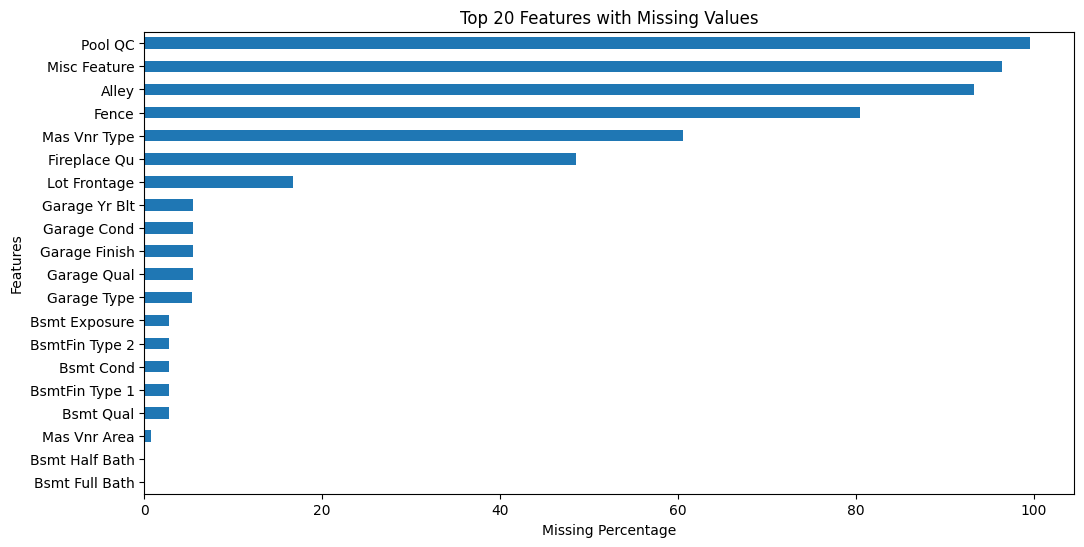

In [ ]:
plt.figure(figsize=(12,6))

missing_summary["Percentage"].head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Features with Missing Values")
plt.xlabel("Missing Percentage")
plt.ylabel("Features")
plt.show()

In [ ]:
df["Pool QC"].value_counts(dropna=False)

,count
Pool QC,
NaN,2917
Ex,4
Gd,4
TA,3
Fa,2


In [ ]:
df["Pool QC"].value_counts(dropna=False)

,count
Pool QC,
NaN,2917
Ex,4
Gd,4
TA,3
Fa,2


In [ ]:
df["Alley"].value_counts(dropna=False)

,count
Alley,
NaN,2732
Grvl,120
Pave,78


In [ ]:
df["Fireplace Qu"].value_counts(dropna=False)

,count
Fireplace Qu,
NaN,1422
Gd,744
TA,600
Fa,75
Po,46
Ex,43


In [ ]:
df["Lot Frontage"].value_counts(dropna=False)

,count
Lot Frontage,
NaN,490
60.0,276
80.0,137
70.0,133
50.0,117
...,...
168.0,1
111.0,1
131.0,1


In [ ]:
none_columns = [
    "Pool QC",
    "Misc Feature",
    "Alley",
    "Fence",
    "Mas Vnr Type",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Bsmt Cond",
    "Bsmt Qual"
]

df[none_columns] = df[none_columns].fillna("None")

In [ ]:
zero_columns = [
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Garage Yr Blt",
    "Garage Cars",
    "Garage Area",
]

df[zero_columns] = df[zero_columns].fillna(0)

In [ ]:
df["Lot Frontage"].isnull().sum()

np.int64(490)

In [ ]:
df["Lot Frontage"].describe()

,Lot Frontage
count,2440.000000
mean,69.224590
std,23.365335
min,21.000000
25%,58.000000
50%,68.000000
75%,80.000000
max,313.000000


In [ ]:
df["Lot Frontage"] = df.groupby("Neighborhood")["Lot Frontage"].transform(
    lambda x: x.fillna(x.median())
)

df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

In [ ]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(
    df["Lot Frontage"].median()
)

In [ ]:
df["Electrical"].value_counts(dropna=False)

,count
Electrical,
SBrkr,2682
FuseA,188
FuseF,50
FuseP,8
NaN,1
Mix,1


In [ ]:
df["Electrical"] = df["Electrical"].fillna(
    df["Electrical"].mode()[0]
)

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
Lot Area,0
Street,0
Alley,0
Lot Shape,0
Land Contour,0


In [ ]:
# Total Bathrooms
df["Total Bathrooms"] = (
    df["Bsmt Full Bath"]
    + (0.5 * df["Bsmt Half Bath"])
    + df["Full Bath"]
    + (0.5 * df["Half Bath"])
)

In [ ]:
df["Total SF"] = (
    df["Total Bsmt SF"] +
    df["1st Flr SF"] +
    df["2nd Flr SF"]
)

In [ ]:
df["House Age"] = df["Yr Sold"] - df["Year Built"]

In [ ]:
df["Remodel Age"] = df["Yr Sold"] - df["Year Remod/Add"]

In [ ]:
df["Total Porch SF"] = (
    df["Open Porch SF"] +
    df["Enclosed Porch"] +
    df["3Ssn Porch"] +
    df["Screen Porch"]
)

In [ ]:
df["Total Outdoor SF"] = (
    df["Wood Deck SF"] +
    df["Total Porch SF"] +
    df["Pool Area"]
)

In [ ]:
# Does the house have a garage?
df["Has Garage"] = (df["Garage Area"] > 0).astype(int)

# Does the house have a basement?
df["Has Basement"] = (df["Total Bsmt SF"] > 0).astype(int)

# Does the house have a fireplace?
df["Has Fireplace"] = (df["Fireplaces"] > 0).astype(int)

# Does the house have a pool?
df["Has Pool"] = (df["Pool Area"] > 0).astype(int)

In [ ]:
df["Living Area Per Room"] = (
    df["Gr Liv Area"] / df["TotRms AbvGrd"]
)

In [ ]:
df["Garage Area Per Car"] = (
    df["Garage Area"] /
    df["Garage Cars"].replace(0, 1)
)

In [ ]:
df["Quality x Condition"] = (
    df["Overall Qual"] *
    df["Overall Cond"]
)

In [ ]:
df["House Age Category"] = pd.cut(
    df["House Age"],
    bins=[0, 10, 30, 60, 200],
    labels=[
        "New",
        "Relatively New",
        "Old",
        "Very Old"
    ]
)

In [ ]:
df["House Size"] = pd.cut(
    df["Total SF"],
    bins=[0, 1500, 2500, 3500, np.inf],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Luxury"
    ]
)

In [ ]:
df["Quality Category"] = pd.cut(
    df["Overall Qual"],
    bins=[0,4,6,8,10],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ]
)

In [ ]:
print(df["House Age Category"].value_counts())
print()

print(df["House Size"].value_counts())
print()

print(df["Quality Category"].value_counts())

House Age Category
Old               1030
New                761
Very Old           592
Relatively New     430
Name: count, dtype: int64

House Size
Medium    1398
Large     1079
Luxury     308
Small      145
Name: count, dtype: int64

Quality Category
Average      1557
Good          952
Low           283
Excellent     138
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Total SF"
]

In [ ]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [ ]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [ ]:
poly_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Total SF"
]

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

poly_array = poly.fit_transform(df[poly_features])

In [ ]:
poly_names = poly.get_feature_names_out(poly_features)

print(poly_names)

['Overall Qual' 'Gr Liv Area' 'Total SF' 'Overall Qual^2'
 'Overall Qual Gr Liv Area' 'Overall Qual Total SF' 'Gr Liv Area^2'
 'Gr Liv Area Total SF' 'Total SF^2']


In [ ]:
poly_df = pd.DataFrame(
    poly_array,
    columns=poly_names,
    index=df.index
)

In [ ]:
df = pd.concat([df, poly_df], axis=1)

In [ ]:
poly_df.head()

,Overall Qual,Gr Liv Area,Total SF,Overall Qual^2,Overall Qual Gr Liv Area,Overall Qual Total SF,Gr Liv Area^2,Gr Liv Area Total SF,Total SF^2
0,6.0,1656.0,2736.0,36.0,9936.0,16416.0,2742336.0,4530816.0,7485696.0
1,5.0,896.0,1778.0,25.0,4480.0,8890.0,802816.0,1593088.0,3161284.0
2,6.0,1329.0,2658.0,36.0,7974.0,15948.0,1766241.0,3532482.0,7064964.0
3,7.0,2110.0,4220.0,49.0,14770.0,29540.0,4452100.0,8904200.0,17808400.0
4,5.0,1629.0,2557.0,25.0,8145.0,12785.0,2653641.0,4165353.0,6538249.0


In [ ]:
target_encode_cols = [
    "Neighborhood",
    "Exterior 1st",
    "Exterior 2nd"
]

In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [63]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.2 MB/s eta 0:00:00


In [64]:
from category_encoders import TargetEncoder

In [65]:
target_encoder = TargetEncoder(
    cols=target_encode_cols,
    smoothing=10
)

In [66]:
X_train_encoded = target_encoder.fit_transform(
    X_train,
    y_train
)

In [67]:
X_test_encoded = target_encoder.transform(X_test)

In [68]:
X_train_encoded.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Total SF^2,Overall Qual,Gr Liv Area,Total SF,Overall Qual^2,Overall Qual Gr Liv Area,Overall Qual Total SF,Gr Liv Area^2,Gr Liv Area Total SF,Total SF^2
381,382,527359050,20,RL,80.0,10400,Pave,None,Reg,Lvl,...,6051600.0,7.0,1370.0,2460.0,49.0,9590.0,17220.0,1876900.0,3370200.0,6051600.0
834,835,906475070,60,RL,80.5,28698,Pave,None,IR2,Low,...,9853321.0,5.0,2126.0,3139.0,25.0,10630.0,15695.0,4519876.0,6673514.0,9853321.0
1898,1899,534429030,90,RL,70.0,9842,Pave,None,Reg,Lvl,...,1498176.0,4.0,1224.0,1224.0,16.0,4896.0,4896.0,1498176.0,1498176.0,1498176.0
678,679,535451170,90,RL,60.0,7200,Pave,None,Reg,Lvl,...,1081600.0,4.0,1040.0,1040.0,16.0,4160.0,4160.0,1081600.0,1081600.0,1081600.0
700,701,902109130,190,RM,63.0,7627,Pave,None,Reg,Lvl,...,5294601.0,4.0,1701.0,2301.0,16.0,6804.0,9204.0,2893401.0,3914001.0,5294601.0


In [69]:
X_test_encoded.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Total SF^2,Overall Qual,Gr Liv Area,Total SF,Overall Qual^2,Overall Qual Gr Liv Area,Overall Qual Total SF,Gr Liv Area^2,Gr Liv Area Total SF,Total SF^2
1357,1358,903427090,70,RM,60.0,5100,Pave,Grvl,Reg,Lvl,...,5080516.0,8.0,1666.0,2254.0,64.0,13328.0,18032.0,2775556.0,3755164.0,5080516.0
2367,2368,527450460,160,RM,21.0,1890,Pave,None,Reg,Lvl,...,2322576.0,6.0,1030.0,1524.0,36.0,6180.0,9144.0,1060900.0,1569720.0,2322576.0
2822,2823,908128100,60,RL,62.0,7162,Pave,None,Reg,Lvl,...,6350400.0,7.0,1724.0,2520.0,49.0,12068.0,17640.0,2972176.0,4344480.0,6350400.0
2126,2127,907135180,20,RL,60.0,8070,Pave,None,Reg,Lvl,...,3920400.0,4.0,990.0,1980.0,16.0,3960.0,7920.0,980100.0,1960200.0,3920400.0
1544,1545,910200080,30,RM,50.0,7000,Pave,None,Reg,Lvl,...,3286969.0,6.0,919.0,1813.0,36.0,5514.0,10878.0,844561.0,1666147.0,3286969.0


In [70]:
comparison = pd.DataFrame({
    "Original Neighborhood": X_train["Neighborhood"].head(10),
    "Encoded Neighborhood": X_train_encoded["Neighborhood"].head(10)
})

comparison

,Original Neighborhood,Encoded Neighborhood
381,NWAmes,186081.133193
834,ClearCr,204762.220904
1898,NAmes,145624.839237
678,NAmes,145624.839237
700,OldTown,124756.488343
2073,ClearCr,204762.220904
2443,NoRidge,327192.633230
2583,NAmes,145624.839237
1915,NAmes,145624.839237
879,CollgCr,200844.829271
